# LLM Figures from Anaylsis Section

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# GPT and Llama models
gpt = pd.read_csv("analysis_gpt/llm_results.csv")
llama = pd.read_csv("analysis/llm_results.csv")

cat = pd.read_csv("analysis_gpt/llm_category_summary.csv")

# False postivies and negatives
fp_gpt = pd.read_csv("analysis_gpt/false_positives.csv")
fn_gpt = pd.read_csv("analysis_gpt/false_negatives.csv")


fp_llama = pd.read_csv("analysis/false_positives.csv")
fn_llama = pd.read_csv("analysis/false_negatives.csv")


## Risk Score Overall

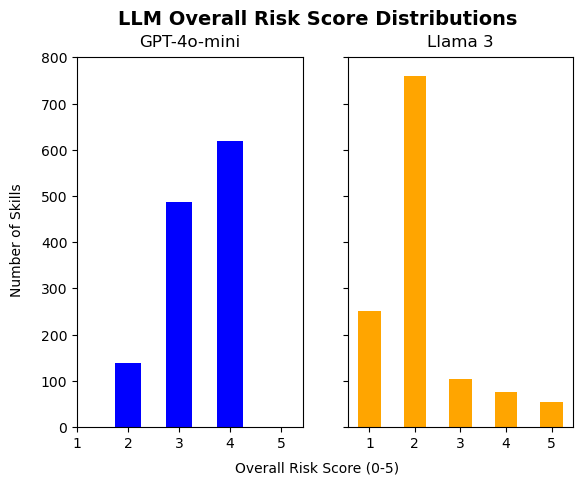

In [36]:
# NOTE: GPT-4o-mini scored 5 only once
fig, axes = plt.subplots(1, 2, sharey=True)
fig.supylabel('Number of Skills', fontsize=10)
fig.supxlabel('Overall Risk Score (0-5)', fontsize=10)

# gpt
gpt_counts = gpt['llm_overall_risk'].value_counts().sort_index()
axes[0].bar(gpt_counts.index, gpt_counts.values, color='blue',width=0.5)
axes[0].set_title('GPT-4o-mini', fontsize=12, pad=8)
axes[0].set_ylim(0, 800)
axes[0].set_xticks([1,2,3,4,5])


#llama
llama_counts = llama['llm_overall_risk'].value_counts().sort_index()
axes[1].bar(llama_counts.index, llama_counts.values, color='orange',width=0.5)
axes[1].set_title('Llama 3', fontsize=12, pad=8)
axes[1].set_xticks([1,2,3,4,5])

plt.suptitle('LLM Overall Risk Score Distributions', fontsize=14,fontweight='bold')
plt.show()

# Avg Risk by Dimension

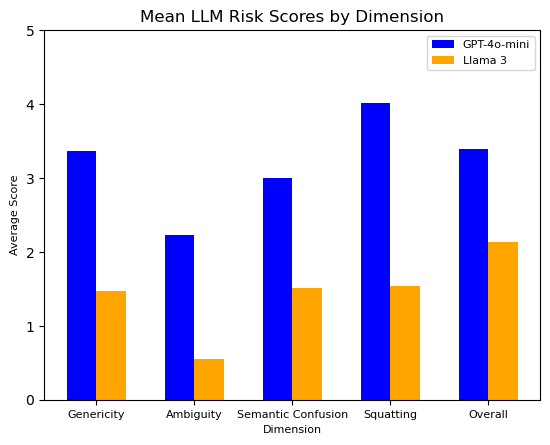

In [ ]:
categories = {
    'Genericity': 'llm_genericity_risk',
    'Ambiguity': 'llm_ambiguity_risk',
    'Semantic Confusion': 'llm_semantic_confusion_risk',
    'Squatting': 'llm_squatting_risk',
    'Overall': 'llm_overall_risk'
}

labels = list(categories.keys())
gpt_means = [gpt[col].mean() for col in categories.values()]
llama_means = [llama[col].mean() for col in categories.values()]

x, width = np.arange(len(labels)), 0.3

fig, ax = plt.subplots()
gpt_graph = ax.bar(x - width/2, gpt_means, width, label='GPT-4o-mini', color="blue")
llama_graph = ax.bar(x + width/2, llama_means, width, label='Llama 3', color="orange")


ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize = 8)
ax.set_ylabel('Average Score', fontsize = 8)
ax.set_xlabel("Dimension",fontsize = 8)
ax.set_title('Mean LLM Risk Scores by Dimension', fontsize=12)
ax.set_ylim(0, 5)
ax.legend(fontsize=8)

plt.show()

# FN/FP

In [59]:
def false_function(gpt_counts, llama_counts, title):
    all_categories = sorted(set(gpt_counts.index) | set(llama_counts.index))
    gpt_counts   = [gpt_counts.get(c, 0) for c in all_categories]
    llama_counts = [llama_counts.get(c, 0) for c in all_categories]

    order = np.argsort([g + l for g, l in zip(gpt_counts, llama_counts)])[::-1]
    all_categories = [all_categories[i]for i in order]
    gpt_counts = [gpt_counts[i] for i in order]
    llama_counts = [llama_counts[i]for i in order]
   
    x, width = np.arange(len(all_categories)), 0.35

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.bar(x - width/2, gpt_counts, width, label='GPT-4o-mini', color="blue")
    ax1.bar(x + width/2, llama_counts, width, label='Llama 3', color="orange")
    ax1.set_xticks(x)
    ax1.set_xticklabels(all_categories, rotation=35, ha='right', fontsize=8)
    ax1.set_ylabel('Number of Skills', fontsize=11)
    ax1.set_title(title, fontsize=12, fontweight='bold')
    ax1.set_ylim(0,30)


    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labels1, fontsize=10)

    plt.show()

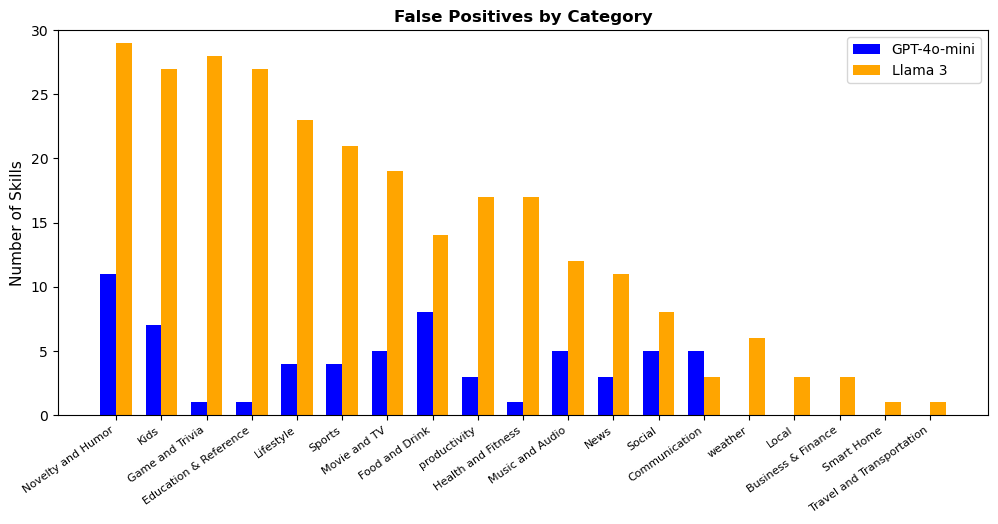

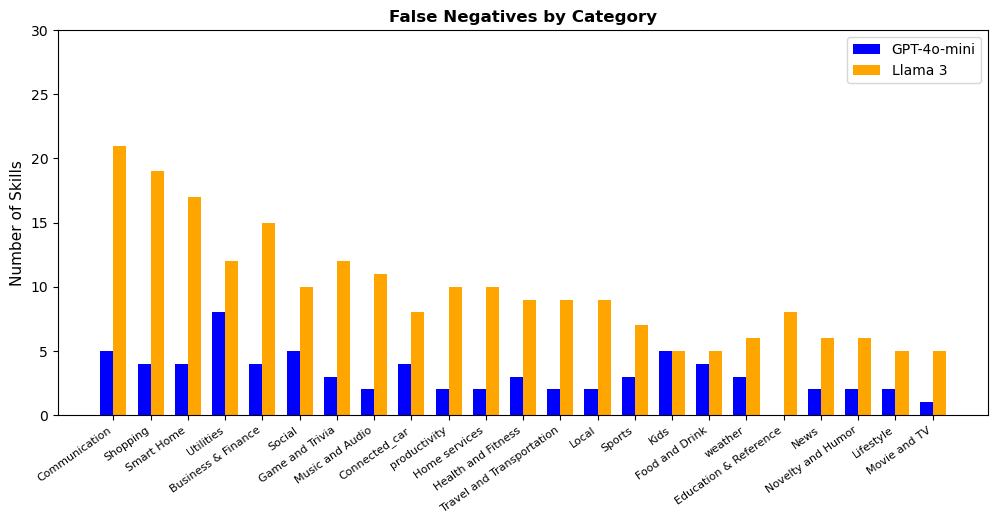

In [ ]:
fp_llama_counts = fp_llama['Category'].value_counts()
fn_llama_counts = fn_llama['Category'].value_counts()

fp_gpt_counts   = fp_gpt['Category'].value_counts()
fn_gpt_counts   = fn_gpt['Category'].value_counts()


false_function(fp_gpt_counts, fp_llama_counts,'False Positives by Category')
false_function(fn_gpt_counts, fn_llama_counts, 'False Negatives by Category')
